##Project Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Conv2D, MaxPooling2D, Flatten,Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import keras

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retinamnist_64.npz to retinamnist_64.npz


In [ ]:
data = np.load("retinamnist_64.npz")

print(data.files)

['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


In [ ]:
#Optional: Load the model from a file
files.upload()

model = keras.models.load_model('CNN_Model.keras')

ValueError: File not found: filepath=CNN_Model.keras. Please ensure the file is an accessible `.keras` zip file.

##Data Preprocessing

In [ ]:
#Data split
X_train = data["train_images"]
y_train = data["train_labels"]

X_val = data["val_images"]
y_val = data["val_labels"]

X_test = data["test_images"]
y_test = data["test_labels"]

In [ ]:
#Pixel data normalization
print(X_train.shape)
X_train = X_train[..., [0,1,2]] / 255.0
X_val = X_val[..., [0,1,2]] / 255.0
X_test = X_test[..., [0,1,2]] / 255.0

"""
X_train = X_train[:5000]
X_val = X_val[:5000]
X_test = X_test[:5000]
y_train = y_train[:5000]
y_val = y_val[:5000]
y_test = y_test[:5000]
"""

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:", X_val.shape, " y_val:", y_val.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

(1080, 64, 64, 3)
X_train: (1080, 64, 64, 3)  y_train: (1080, 1)
X_val: (120, 64, 64, 3)  y_val: (120, 1)
X_test: (400, 64, 64, 3)  y_test: (400, 1)


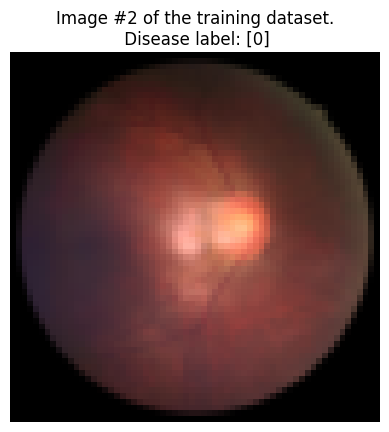

In [ ]:
#Show example images
def disp_img(image_num, dataset):
  if dataset == "training":
    plt.imshow(X_train[image_num].squeeze())
  elif dataset == "validation":
    plt.imshow(X_val[image_num].squeeze())
  elif dataset == "testing":
    plt.imshow(X_test[image_num].squeeze())

  plt.title(f"Image #{image_num+1} of the {dataset} dataset.\n Disease label: {y_train[image_num]}")

  plt.axis("off")
  plt.show()

disp_img(1, "training")

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encode = encoder.fit_transform(y_train)
print('No. of classes: ',encoder.classes_)
# there are 5 difference outcomes when one image is processed

y_train_hotcode = to_categorical(y_train,5)
y_val_hotcode = to_categorical(y_val,5)
y_test_hotcode = to_categorical(y_test,5)
# convert to categorical
print(y_train_hotcode[:5])

No. of classes:  [0 1 2 3 4]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##Building the model

In [ ]:
model = Sequential([
    Input(shape = (64,64,3)),
    Conv2D(16,2,activation='relu'),
    MaxPooling2D(2), # shrinks to 32x32

    Conv2D(32,2,activation='relu'),
    MaxPooling2D(2), # shrinks to 16x16

    Conv2D(64,2,activation='relu'),
    MaxPooling2D(2), # shrinks to 8x8

    Flatten(), #converts to a 1D array
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(5,activation='softmax')

])
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss="categorical_crossentropy"
)

estop= EarlyStopping(monitor = 'val_loss',patience = 3,restore_best_weights=True)
model.fit(X_train,y_train_hotcode,validation_data = (X_val,y_val_hotcode),batch_size = 32,epochs = 25,callbacks = [estop])

Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 1.4785 - val_loss: 1.3480
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 1.3582 - val_loss: 1.3187
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 1.3397 - val_loss: 1.2968
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 1.3145 - val_loss: 1.2688
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 1.2997 - val_loss: 1.2240
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 1.2500 - val_loss: 1.1886
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 1.2178 - val_loss: 1.1307
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 1.2067 - val_loss: 1.1150
Epoch 9/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 1.1847 - val_loss: 1.0934
Epoch 10/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 1.1786 - val_loss: 1.0848
Epoch 11/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 1.1923 - val_loss: 1.1089
Epoch 12/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 1

<Axes: >

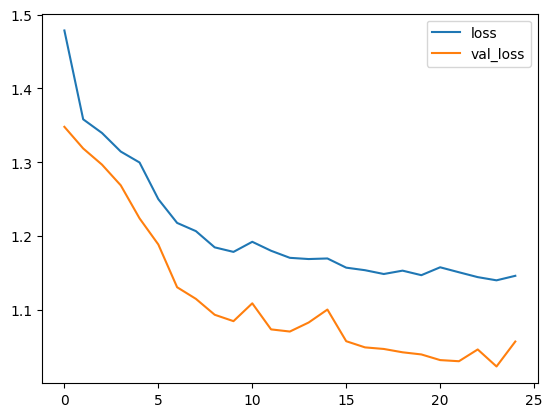

In [ ]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [ ]:

pred = np.argmax(model.predict(X_test),axis = 1)
print(classification_report(y_test,pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
              precision    recall  f1-score   support

           0       0.71      0.79      0.74       174
           1       0.00      0.00      0.00        46
           2       0.36      0.51      0.42        92
           3       0.40      0.44      0.42        68
           4       0.00      0.00      0.00        20

    accuracy                           0.54       400
   macro avg       0.29      0.35      0.32       400
weighted avg       0.46      0.54      0.49       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


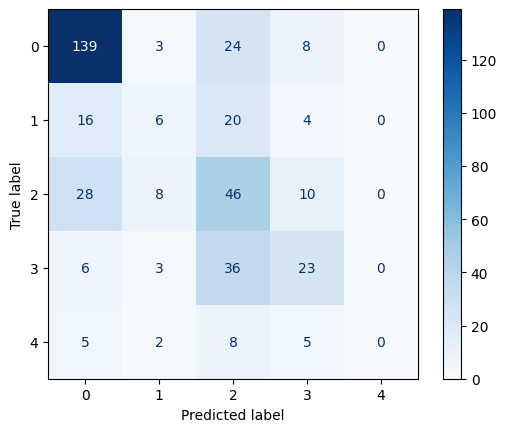

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=encoder.classes_,cmap = 'Blues')

In [ ]:
y_proba = model.predict(X_test)
y_proba_slice = y_proba[:,1]
print(y_proba[:5])
print(y_proba_slice[:5])



In [ ]:
n_classes = y_test_hotcode.shape[1]

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_hotcode[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test_hotcode[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # random guessing curve
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Class Distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across Datasets', fontsize=16)

# Training Set
sns.countplot(x=y_train.flatten(), ax=axes[0])
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')

# Validation Set
sns.countplot(x=y_val.flatten(), ax=axes[1])
axes[1].set_title('Validation Set Class Distribution')
axes[1].set_xlabel('Class Label')
axes[1].set_ylabel('Count')

# Test Set
sns.countplot(x=y_test.flatten(), ax=axes[2])
axes[2].set_title('Test Set Class Distribution')
axes[2].set_xlabel('Class Label')
axes[2].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##Saving the model

In [ ]:
#Only run this code when you want to save the model to a file
model.save('CNN_Model.keras')